# Notebook de processamento dos dados extraidos

In [71]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy.stats import spearmanr


# Estilo global dos gráficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

PARQUET_POSTS = Path("posts.parquet")

In [72]:
df = pl.read_parquet(PARQUET_POSTS)

# 1.0 Qualidade e limpeza dos dados

## 1.1 Visão geral do dataset


 - Qual a estrutura do dataset(shape())?

Shape: 9726198 Linhas e 20 colunas


In [73]:
df.shape[0]


9726198

In [74]:
df.shape[1]

20

In [75]:
# Tamanho na memoria RAM
df.estimated_size('mb')

1393.76331615448

In [76]:
# Colunas e seus tipos
df.schema

Schema([('post_id', String),
        ('username', String),
        ('inf_category', String),
        ('followers', Int64),
        ('followees', Int64),
        ('posts_total', Int64),
        ('is_verified', Boolean),
        ('data', String),
        ('timestamp_unix', Int64),
        ('likes', Int64),
        ('comments_count', Int64),
        ('post_type', String),
        ('n_imagens', Int64),
        ('aspect_ratio', Float64),
        ('is_sponsored', Boolean),
        ('n_hashtags', Int64),
        ('n_usertags', Int64),
        ('caption_len', Int64),
        ('has_location', Boolean),
        ('accessibility', String)])

 - Qual a % de nulos por coluna?

In [77]:
df.null_count()

post_id,username,inf_category,followers,followees,posts_total,is_verified,data,timestamp_unix,likes,comments_count,post_type,n_imagens,aspect_ratio,is_sponsored,n_hashtags,n_usertags,caption_len,has_location,accessibility
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Não há nulos

 - Quantos influenciadores únicos? 


In [78]:
posts_inf = df.group_by("username").agg(pl.len().alias("n_posts")).sort("n_posts",descending=True)

print(f"Influenciadores unicos: {posts_inf.shape[0]}")

Influenciadores unicos: 33840


In [79]:
posts_inf

username,n_posts
str,u32
"""thecorporatemummy""",300
"""ecsupplyinc""",300
"""emilyreviews""",300
"""foodandwine""",300
"""marjanialadin""",300
…,…
"""simplesmente.josi""",1
"""asdasmdnlasndlknklasnd1""",1
"""macarenapaz_xox""",1


 - Quantos posts por influenciador?

In [80]:
print(f"Estatistica de posts por influenciador: {posts_inf["n_posts"].describe()}")

Estatistica de posts por influenciador: shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 33840.0    │
│ null_count ┆ 0.0        │
│ mean       ┆ 287.417199 │
│ std        ┆ 37.518166  │
│ min        ┆ 1.0        │
│ 25%        ┆ 297.0      │
│ 50%        ┆ 300.0      │
│ 75%        ┆ 300.0      │
│ max        ┆ 300.0      │
└────────────┴────────────┘


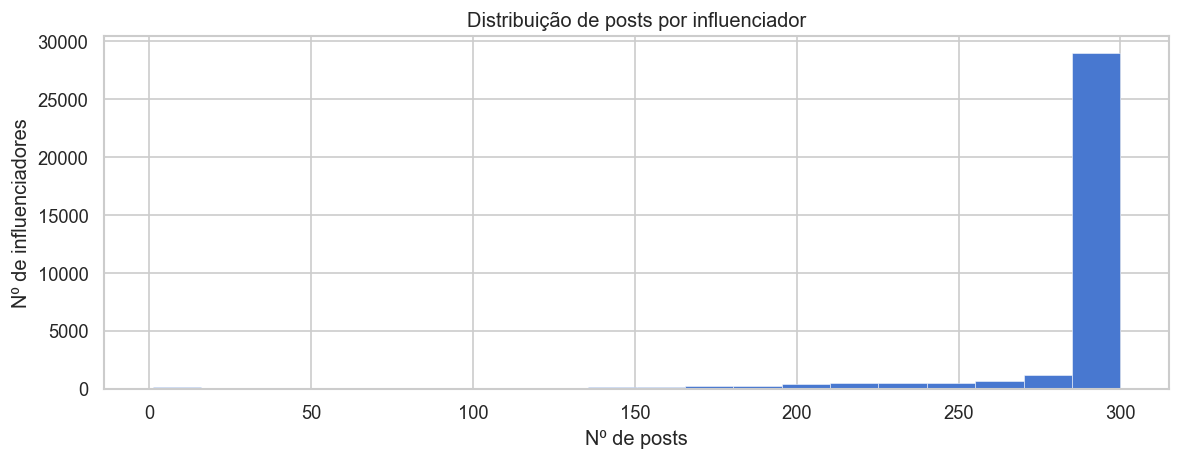

In [81]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(
    posts_inf["n_posts"].to_numpy(),
    bins=20,
    color=sns.color_palette("muted")[0],
    edgecolor="white", linewidth=0.3,
)
ax.set_xlabel("Nº de posts")
ax.set_ylabel("Nº de influenciadores")
ax.set_title("Distribuição de posts por influenciador")
plt.tight_layout()
plt.show()

A grande maioria tem 300 posts

- Quantos posts não tem categoria(inf_category)?

In [82]:
sem_categoria = df.filter(
    pl.col("inf_category").is_null() | (pl.col("inf_category") == "")
)
print(f"Posts sem categoria: {sem_categoria.shape[0]:,}  ({sem_categoria.shape[0]/df.shape[0]*100:.4f}%)")
print()
print("Quem são:")
print(
    sem_categoria
    .select(["username", "inf_category", "followers", "likes", "comments_count"])
)

Posts sem categoria: 159,547  (1.6404%)

Quem são:
shape: (159_547, 5)
┌───────────────────┬──────────────┬───────────┬───────┬────────────────┐
│ username          ┆ inf_category ┆ followers ┆ likes ┆ comments_count │
│ ---               ┆ ---          ┆ ---       ┆ ---   ┆ ---            │
│ str               ┆ str          ┆ i64       ┆ i64   ┆ i64            │
╞═══════════════════╪══════════════╪═══════════╪═══════╪════════════════╡
│ vanessachristinne ┆              ┆ 0         ┆ 5619  ┆ 0              │
│ vanessachristinne ┆              ┆ 0         ┆ 3874  ┆ 0              │
│ vanessachristinne ┆              ┆ 0         ┆ 4097  ┆ 0              │
│ vanessachristinne ┆              ┆ 0         ┆ 5035  ┆ 0              │
│ vanessachristinne ┆              ┆ 0         ┆ 7727  ┆ 0              │
│ …                 ┆ …            ┆ …         ┆ …     ┆ …              │
│ thefarmerswife__  ┆              ┆ 0         ┆ 248   ┆ 0              │
│ thefarmerswife__  ┆              ┆ 0   

In [83]:
usernames = sem_categoria["username"].unique().to_list()

In [84]:
import pandas as pd
df_inf = pd.read_csv("dataframe_influencers.csv")
df_inf.loc[df_inf["Username"].isin(usernames)]

,Username,Category,Followers,Followees,Posts


Os posts que não tem Categoria são os mesmos que não tem Seguidores(followers = 0), eles não estão no arquivo que mapeia os metadados dos influenciadores

## 1.2 Qualidade do lookup de followers

In [85]:
total = df.shape[0]

sem_followers     = df.filter(pl.col("followers").is_null()).shape[0]

followers_zero    = df.filter(pl.col("followers") == 0).shape[0]

followers_ok      = df.filter(pl.col("followers") > 0).shape[0]

print(f"Total de posts:      {total}")
print(f"Com followers > 0:   {followers_ok}  ({followers_ok/total*100:.1f}%)")
print(f"Com followers = 0:   {followers_zero}  ({followers_zero/total*100:.1f}%)")
print(f"Com followers nulo:  {sem_followers}  ({sem_followers/total*100:.1f}%)")

Total de posts:      9726198
Com followers > 0:   9566651  (98.4%)
Com followers = 0:   159547  (1.6%)
Com followers nulo:  0  (0.0%)


159547 Posts que não constam o numero de seguidores (followers)

## 1.3 Cobertura temporal

- Periodo minimo e maximo do dataset

In [86]:
df = df.with_columns(
    pl.col("data").str.to_date("%Y-%m-%d", strict=False).alias("data_dt")
)

data_min = df["data_dt"].min()
data_max = df["data_dt"].max()
nulos_data = df["data_dt"].null_count()

print(f"Período:                  {data_min}  ->  {data_max}")
print(f"Posts sem data válida:    {nulos_data}")

Período:                  2012-02-10  ->  2019-05-15
Posts sem data válida:    0


- Alguma categoria tem concentração temporal diferente das outras?

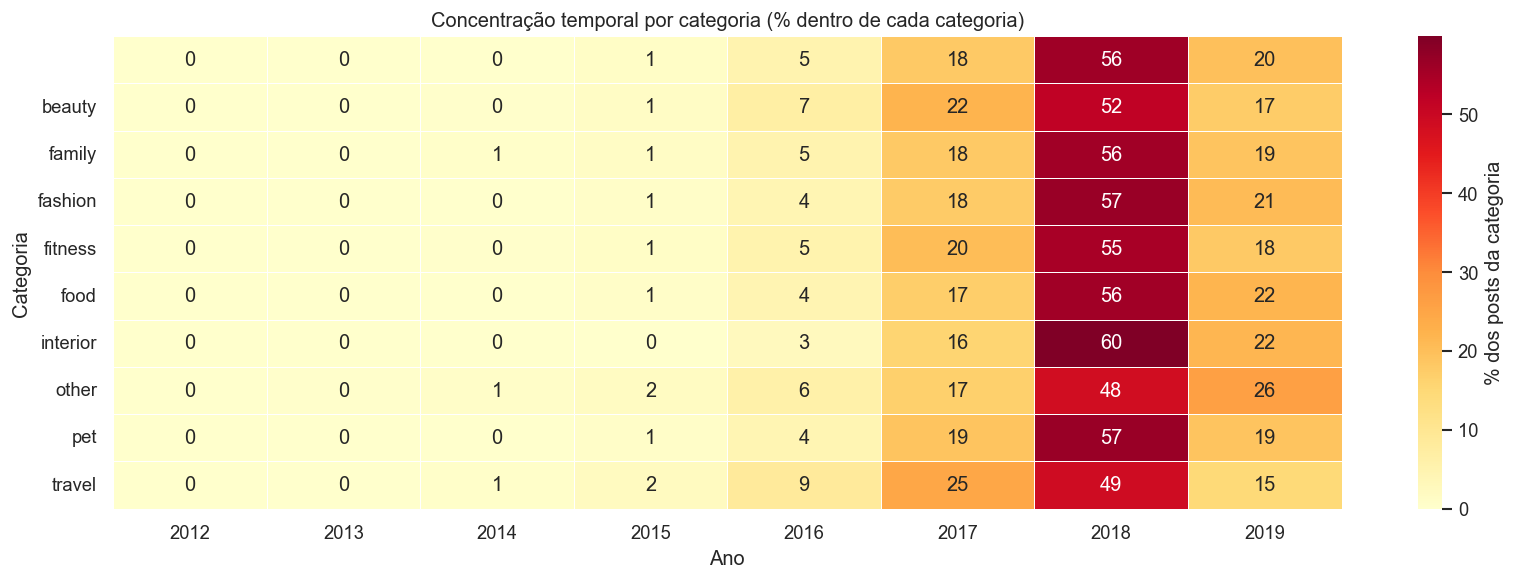

In [87]:
cat_ano = (
    df.filter(pl.col("data_dt").is_not_null())
    .with_columns(pl.col("data_dt").dt.year().alias("ano"))
    .group_by(["inf_category", "ano"])
    .agg(pl.len().alias("n"))
    .sort(["inf_category", "ano"])
    .to_pandas()
)

pivot = cat_ano.pivot_table(index="inf_category", columns="ano", values="n", fill_value=0)
# Normaliza cada linha para somar 100%
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    pivot_pct, ax=ax,
    cmap="YlOrRd", annot=True, fmt=".0f",
    linewidths=0.3,
    cbar_kws={"label": "% dos posts da categoria"},
)
ax.set_title("Concentração temporal por categoria (% dentro de cada categoria)")
ax.set_xlabel("Ano")
ax.set_ylabel("Categoria")
plt.tight_layout()
plt.show()

## 1.4 Outliers e casos problemáticos

- Posts com likes = 0 e comments = 0 

In [88]:
print(f"Posts com zero likes: {df.filter((pl.col("likes") == 0)).shape[0]}")
print(f"Posts com zero commentarios: {df.filter((pl.col("comments_count") == 0)).shape[0]}")


Posts com zero likes: 3044
Posts com zero commentarios: 8830004


In [89]:
zeros = df.filter((pl.col("likes") == 0) & (pl.col("comments_count") == 0))
print(f"Posts com 0 likes e comments: {zeros.shape[0]:,}  ({zeros.shape[0]/total*100:.2f}%)")
print()
# Distribuição desses zeros por categoria
print("Por categoria:")
print(
    zeros.group_by("inf_category")
    .agg(pl.len().alias("n"))
    .sort("n", descending=True)
)

Posts com 0 likes e comments: 3,038  (0.03%)

Por categoria:
shape: (9, 2)
┌──────────────┬──────┐
│ inf_category ┆ n    │
│ ---          ┆ ---  │
│ str          ┆ u32  │
╞══════════════╪══════╡
│ other        ┆ 2215 │
│ travel       ┆ 299  │
│ family       ┆ 195  │
│ food         ┆ 134  │
│ pet          ┆ 76   │
│ fashion      ┆ 72   │
│              ┆ 30   │
│ beauty       ┆ 14   │
│ fitness      ┆ 3    │
└──────────────┴──────┘


- Influenciadores com followers < 100 

In [90]:
df.filter((pl.col("followers") > 0) & (pl.col("followers") < 100)).shape[0]

0

In [91]:
df.filter((pl.col('followers')==0)).shape[0]

159547

0 influenciadores entre 0 e 100 seguidores

159.547 influenciadores com 0 seguidores

## 1.5 Decisões de filtragem

Informações importantes:

- Total de Registros:                      9.726.198
- Registros com Followers = 0 :            159.547   (1,64%)
- Registros com Likes = 0 e Comments = 0 : 3.038     (0,03%)
- Posts sem categoria:                     159.547   (1,64%)

Os posts sem categorias são os mesmos sem Followers. Acontece que os autores desses posts não estão mapeados no dataset de Influenciadores, não são posts fantasmas.

DECISÕES TOMADAS

- Remover os 159.547 posts onde followers = 0. Sem o followers não podemos calcular ER, que é a métrica central da pesquisa
- Manter registros com Likes = 0 AND Comments = 0 , mas marcando eles com uma flag("engajamento_zero")

In [92]:
antes = df.shape[0]

df_limpo = df.filter(pl.col("followers") > 0)

removidos = antes - df_limpo.shape[0]
print(f"Removidos (followers = 0): {removidos:,}  ({removidos/antes*100:.2f}%)")

#Flag: engajamento zero
df_limpo = df_limpo.with_columns(
    ((pl.col("likes") == 0) & (pl.col("comments_count") == 0))
    .alias("engajamento_zero")
)

print(f"Posts marcados engajamento_zero: {df_limpo['engajamento_zero'].sum():,}")
print(f"\nDataset final: {df_limpo.shape[0]:,} linhas  ({df_limpo.shape[0]/antes*100:.2f}% do original)")

df_limpo.write_parquet("posts_limpo.parquet", compression="zstd")
print("Salvo: posts_limpo.parquet")

Removidos (followers = 0): 159,547  (1.64%)
Posts marcados engajamento_zero: 3,008

Dataset final: 9,566,651 linhas  (98.36% do original)
Salvo: posts_limpo.parquet


# 2.0 Calculos Base

In [93]:
df = pl.read_parquet("posts_limpo.parquet")
df.shape[0]


9566651

## 2.1 Cálculo de ER

- er_classico = (likes + comments) / followers *100
- er_weighted = (likesx1 + commentsx2) / followers *100

Em uma etapa futura faremos uma validação empirica do peso em er_weighetd, onde diferentes combinações serão testadas.

In [94]:
df = df.with_columns([
    ((pl.col("likes") + pl.col("comments_count")) / pl.col("followers") * 100)
    .alias("er_classico"),

    ((pl.col("likes") * 1 + pl.col("comments_count") * 2) / pl.col("followers") * 100)
    .alias("er_weighted"),
])

In [95]:
df.head()

post_id,username,inf_category,followers,followees,posts_total,is_verified,data,timestamp_unix,likes,comments_count,post_type,n_imagens,aspect_ratio,is_sponsored,n_hashtags,n_usertags,caption_len,has_location,accessibility,data_dt,engajamento_zero,er_classico,er_weighted
str,str,str,i64,i64,i64,bool,str,i64,i64,i64,str,i64,f64,bool,i64,i64,i64,bool,str,date,bool,f64,f64
"""BmlIb5Xld5f""","""00s_supermodels""","""fashion""",2031,53,2520,false,"""2018-08-17""",1534509290,51,2,"""image""",1,0.8,false,18,1,257,false,"""""",2018-08-17,false,2.609552,2.708026
"""BmlI2LPlblP""","""00s_supermodels""","""fashion""",2031,53,2520,false,"""2018-08-17""",1534509505,89,0,"""image""",1,0.8,false,17,1,279,false,"""""",2018-08-17,false,4.382078,4.382078
"""BmoH1VclTxO""","""00s_supermodels""","""fashion""",2031,53,2520,false,"""2018-08-18""",1534609638,94,0,"""image""",1,0.8,false,16,1,228,false,"""""",2018-08-18,false,4.628262,4.628262
"""Bmd0fuolkUZ""","""00s_supermodels""","""fashion""",2031,53,2520,false,"""2018-08-14""",1534263955,66,4,"""carousel""",2,0.8,true,17,1,282,false,"""Image may contain: 2 people, i…",2018-08-14,false,3.446578,3.643525
"""Bmd445DFh7t""","""00s_supermodels""","""fashion""",2031,53,2520,false,"""2018-08-14""",1534266258,64,0,"""carousel""",4,0.8,false,18,1,255,false,"""Image may contain: 1 person, c…",2018-08-14,false,3.151157,3.151157


In [96]:
# er_weighted < er_classico ?
df.filter(pl.col("er_weighted") < pl.col("er_classico")).shape[0]

0

- er por tipo

In [97]:
er_por_tipo = (
    df.filter(pl.col("er_classico") > 0)
    .group_by("post_type")
    .agg([
        pl.len().alias("n_posts"),
        pl.col("er_classico").median().round(4).alias("er_cl_mediana"),
        pl.col("er_weighted").median().round(4).alias("er_wt_mediana"),
        pl.col("er_classico").mean().round(4).alias("er_cl_media"),
        pl.col("er_weighted").mean().round(4).alias("er_wt_media"),
    ])
    .sort("er_cl_mediana", descending=True)
)
print(er_por_tipo)

shape: (2, 6)
┌───────────┬─────────┬───────────────┬───────────────┬─────────────┬─────────────┐
│ post_type ┆ n_posts ┆ er_cl_mediana ┆ er_wt_mediana ┆ er_cl_media ┆ er_wt_media │
│ ---       ┆ ---     ┆ ---           ┆ ---           ┆ ---         ┆ ---         │
│ str       ┆ u32     ┆ f64           ┆ f64           ┆ f64         ┆ f64         │
╞═══════════╪═════════╪═══════════════╪═══════════════╪═════════════╪═════════════╡
│ carousel  ┆ 1109050 ┆ 3.1191        ┆ 3.1329        ┆ 4.6611      ┆ 4.6864      │
│ image     ┆ 8454593 ┆ 2.9341        ┆ 2.9457        ┆ 4.1925      ┆ 4.213       │
└───────────┴─────────┴───────────────┴───────────────┴─────────────┴─────────────┘


Posts do tipo carrousel tem mais engajamento que posts do tipo imagem. O dataset não contem posts do tipo video

## 2.2 Segmentação por tamanho de conta (bucket_followers)

Fonte: https://trackier.com/guide-to-influencer-tier-nano-creators-to-megastars/

In [98]:
df = df.with_columns(
    pl.when(pl.col("followers") <= 10_000)         .then(pl.lit("nano"))
    .when(pl.col("followers") <= 100_000)           .then(pl.lit("micro"))
    .when(pl.col("followers") <= 500_000)           .then(pl.lit("mid-tier"))
    .when(pl.col("followers") <= 1_000_000)         .then(pl.lit("macro"))
    .otherwise(                                      pl.lit("mega"))
    .alias("bucket_followers")
)

ORDEM_BUCKET = ["nano", "micro", "mid-tier", "macro", "mega"]

- Distribuição de posts e influenciadores

In [99]:
total = df.shape[0]
df.group_by("bucket_followers").agg([
        pl.len().alias("n_posts"),
        pl.col("username").n_unique().alias("n_influenciadores"),
        pl.col("er_classico").median().round(4).alias("er_cl_mediano"),
        pl.col("er_weighted").median().round(4).alias("er_wt_mediano"),
    ]).with_columns(
        (pl.col("n_posts") / total * 100).round(2).alias("pct_posts")
    ).sort(
        pl.col("bucket_followers").cast(pl.Enum(ORDEM_BUCKET))
    )

bucket_followers,n_posts,n_influenciadores,er_cl_mediano,er_wt_mediano,pct_posts
str,u32,u32,f64,f64,f64
"""nano""",3524869,12282,3.7157,3.7355,36.85
"""micro""",4478220,15464,2.7102,2.7209,46.81
"""mid-tier""",1156707,3996,2.4041,2.4086,12.09
"""macro""",193495,669,2.2888,2.292,2.02
"""mega""",213360,738,2.1472,2.1492,2.23


- Distribuição de segmento e categoria

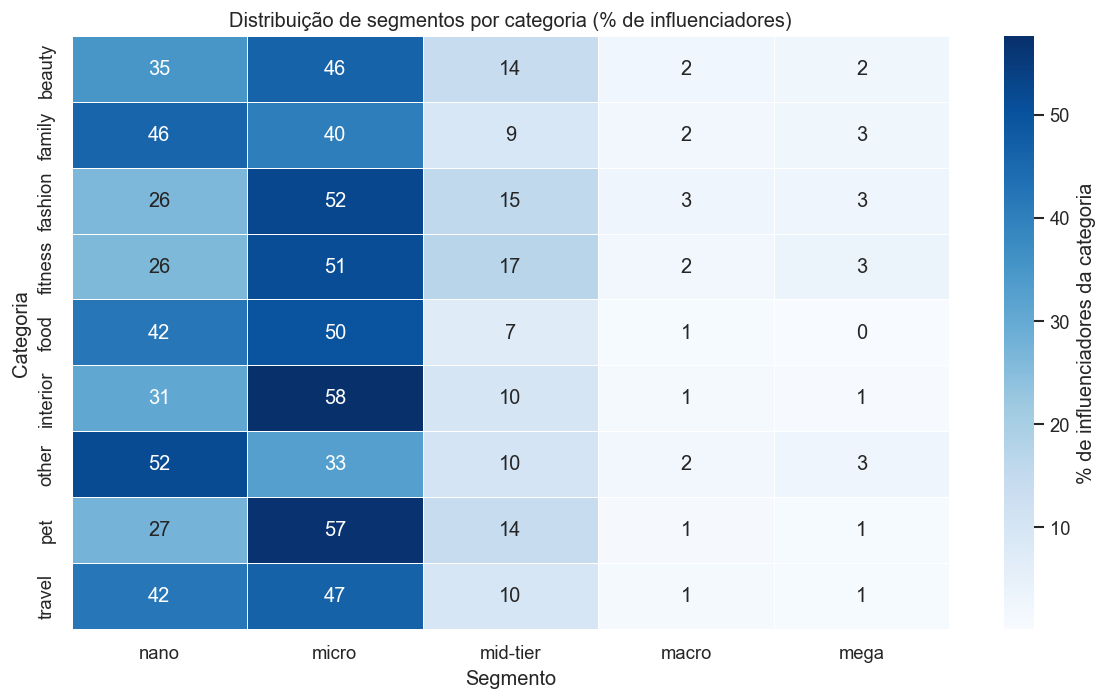

In [100]:
cat_bucket = (
    df.group_by(["inf_category", "bucket_followers"])
    .agg(pl.col("username").n_unique().alias("n"))
    .to_pandas()
)

pivot = cat_bucket.pivot_table(
    index="inf_category", columns="bucket_followers",
    values="n", fill_value=0
)[ORDEM_BUCKET]

pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    pivot_pct, ax=ax,
    cmap="Blues", annot=True, fmt=".0f",
    linewidths=0.3,
    cbar_kws={"label": "% de influenciadores da categoria"},
)
ax.set_title("Distribuição de segmentos por categoria (% de influenciadores)")
ax.set_xlabel("Segmento")
ax.set_ylabel("Categoria")
plt.tight_layout()
plt.show()

## 2.3 Buckets de ER

### 2.3.1 Por padrão da industria
   LOW    : ER < 1%\
   MEDIUM : 1% ≤ ER < 3.5%\
   HIGH   : 3.5% ≤ ER < 6%\
   VIRAL  : ER ≥ 6%

In [101]:
ORDEM_ER_IND = ["LOW", "MEDIUM", "HIGH", "VIRAL"]

df = df.with_columns(
    pl.when(pl.col("er_classico") < 1)    .then(pl.lit("LOW"))
    .when(pl.col("er_classico") < 3.5)    .then(pl.lit("MEDIUM"))
    .when(pl.col("er_classico") < 6)      .then(pl.lit("HIGH"))
    .otherwise(                            pl.lit("VIRAL"))
    .alias("er_bucket_industria")
)

dist_ind = (
    df.group_by("er_bucket_industria")
    .agg(pl.len().alias("n_posts"))
    .with_columns(
        (pl.col("n_posts") / total * 100).round(2).alias("pct")
    )
    .sort(pl.col("er_bucket_industria").cast(pl.Enum(ORDEM_ER_IND)))
)


In [102]:
dist_ind

er_bucket_industria,n_posts,pct
str,u32,f64
"""LOW""",1411562,14.76
"""MEDIUM""",4072077,42.57
"""HIGH""",2048165,21.41
"""VIRAL""",2034847,21.27


### 2.3.2 Por percentil interno do dataset

Divide os posts em quartis pelo er_classico do próprio dataset. Cada quartil contém exatamente 25% dos posts por construção.

In [103]:
ORDEM_ER_PERC = ["Q1", "Q2", "Q3", "Q4"]

q25 = df["er_classico"].quantile(0.25)
q50 = df["er_classico"].quantile(0.50)
q75 = df["er_classico"].quantile(0.75)

print(f"Cortes percentis do er_classico:")
print(f"  Q1 (p0  - p25): ER < {q25:.4f}")
print(f"  Q2 (p25 - p50): {q25:.4f} ≤ ER < {q50:.4f}")
print(f"  Q3 (p50 - p75): {q50:.4f} ≤ ER < {q75:.4f}")
print(f"  Q4 (p75 - p100): ER ≥ {q75:.4f}")

df = df.with_columns(
    pl.when(pl.col("er_classico") < q25)  .then(pl.lit("Q1"))
    .when(pl.col("er_classico") < q50)    .then(pl.lit("Q2"))
    .when(pl.col("er_classico") < q75)    .then(pl.lit("Q3"))
    .otherwise(                            pl.lit("Q4"))
    .alias("er_bucket_percentil")
)

Cortes percentis do er_classico:
  Q1 (p0  - p25): ER < 1.5183
  Q2 (p25 - p50): 1.5183 ≤ ER < 2.9541
  Q3 (p50 - p75): 2.9541 ≤ ER < 5.4022
  Q4 (p75 - p100): ER ≥ 5.4022


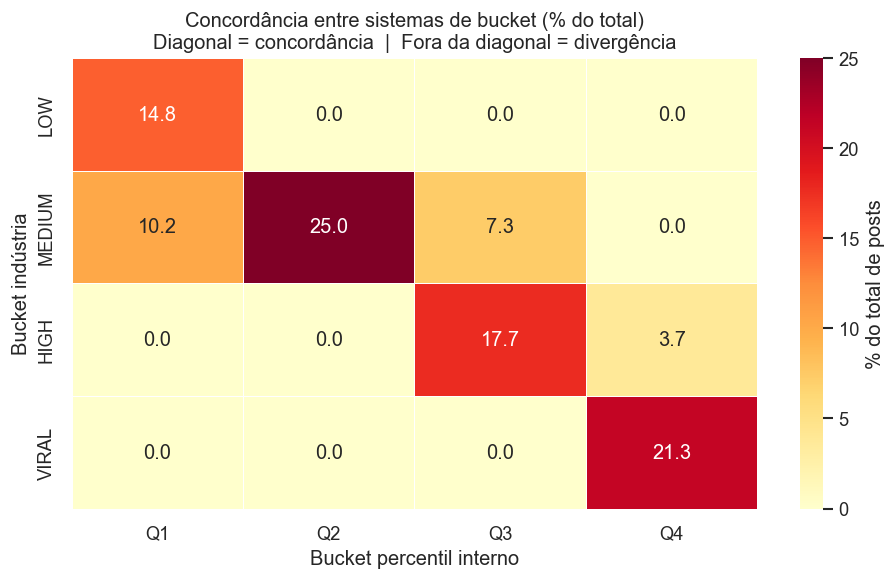

In [104]:
#Tabela de contingência: indústria × percentil
contingencia = (
    df.group_by(["er_bucket_industria", "er_bucket_percentil"])
    .agg(pl.len().alias("n"))
    .to_pandas()
    .pivot_table(
        index="er_bucket_industria",
        columns="er_bucket_percentil",
        values="n",
        fill_value=0,
    )
    .reindex(index=ORDEM_ER_IND, columns=ORDEM_ER_PERC, fill_value=0)
)

contingencia_pct = (contingencia / total * 100).round(2)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    contingencia_pct, ax=ax,
    cmap="YlOrRd", annot=True, fmt=".1f",
    linewidths=0.4,
    cbar_kws={"label": "% do total de posts"},
)
ax.set_title(
    "Concordância entre sistemas de bucket (% do total)\n"
    "Diagonal = concordância  |  Fora da diagonal = divergência"
)
ax.set_xlabel("Bucket percentil interno")
ax.set_ylabel("Bucket indústria")
plt.tight_layout()
plt.show()


Os dois concordam em 78,7% dos posts e discordam em 21,3%

## Salvar parquet posts_processado

In [105]:
df.write_parquet("posts_processado.parquet", compression="zstd")
print(f"Salvo: posts_processado.parquet")
print(f"Shape: {df.shape[0]:,} x {df.shape[1]} colunas")
print()
print("Colunas finais:")
print(df.columns)

Salvo: posts_processado.parquet
Shape: 9,566,651 x 27 colunas

Colunas finais:
['post_id', 'username', 'inf_category', 'followers', 'followees', 'posts_total', 'is_verified', 'data', 'timestamp_unix', 'likes', 'comments_count', 'post_type', 'n_imagens', 'aspect_ratio', 'is_sponsored', 'n_hashtags', 'n_usertags', 'caption_len', 'has_location', 'accessibility', 'data_dt', 'engajamento_zero', 'er_classico', 'er_weighted', 'bucket_followers', 'er_bucket_industria', 'er_bucket_percentil']


# 3.0 EDA

In [106]:
df = pl.read_parquet("posts_processado.parquet")

In [107]:
ORDEM_BUCKET  = ["nano", "micro", "mid-tier", "macro", "mega"]
ORDEM_ER_IND  = ["LOW", "MEDIUM", "HIGH", "VIRAL"]
ORDEM_ER_PERC = ["Q1", "Q2", "Q3", "Q4"]

In [108]:
total = df.shape[0]
total

9566651

In [109]:
df.columns

['post_id',
 'username',
 'inf_category',
 'followers',
 'followees',
 'posts_total',
 'is_verified',
 'data',
 'timestamp_unix',
 'likes',
 'comments_count',
 'post_type',
 'n_imagens',
 'aspect_ratio',
 'is_sponsored',
 'n_hashtags',
 'n_usertags',
 'caption_len',
 'has_location',
 'accessibility',
 'data_dt',
 'engajamento_zero',
 'er_classico',
 'er_weighted',
 'bucket_followers',
 'er_bucket_industria',
 'er_bucket_percentil']

## 3.1 Perfil geral do dataset

- Proporção de tipos de posts

Anteriormente ja vimos que o dataset não contem posts do tipo video

In [110]:
df.group_by("post_type").agg(pl.len().alias("n")).with_columns((pl.col("n")/total*100).round(2).alias("pct"))

post_type,n,pct
str,u32,f64
"""carousel""",1109188,11.59
"""image""",8457463,88.41


- Posts patrocinados por categoria

In [111]:
patrocinado_cat = df.group_by("inf_category").agg([
    pl.len().alias("total"),
    pl.col("is_sponsored").sum().alias("n_sponsored"),
]).with_columns(
    (pl.col("n_sponsored") / pl.col("total") * 100).round(2).alias("pct_sponsored")
).sort("pct_sponsored", descending=True)

patrocinado_cat

inf_category,total,n_sponsored,pct_sponsored
str,u32,u32,f64
"""food""",1019624,71820,7.04
"""family""",1147123,77464,6.75
"""fashion""",3356443,211318,6.3
"""interior""",343490,17290,5.03
"""beauty""",428842,20492,4.78
"""other""",1599096,74101,4.63
"""pet""",167381,7328,4.38
"""travel""",1190935,47540,3.99
"""fitness""",313717,11607,3.7


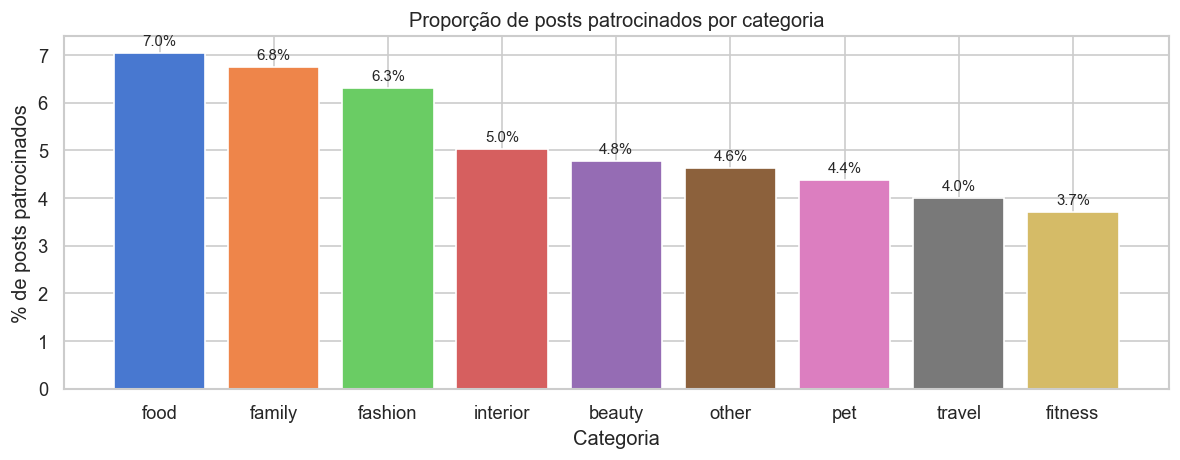

In [112]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    patrocinado_cat["inf_category"].to_list(),
    patrocinado_cat["pct_sponsored"].to_list(),
    color=sns.color_palette("muted", len(patrocinado_cat)),
)
for bar, pct in zip(ax.patches, patrocinado_cat["pct_sponsored"].to_list()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("% de posts patrocinados")
ax.set_xlabel("Categoria")
ax.set_title("Proporção de posts patrocinados por categoria")
plt.tight_layout()
plt.show()

- N° de hashtags por categoria

In [113]:
df.group_by("inf_category").agg([
    pl.col("n_hashtags").mean().alias("mean_hashtags"),
    pl.col("n_hashtags").median().alias("median_hashtags"),
    pl.col("n_hashtags").max().alias("max_hashtags"),
    ]).sort("mean_hashtags",descending=True)

inf_category,mean_hashtags,median_hashtags,max_hashtags
str,f64,f64,i64
"""interior""",11.008344,7.0,114
"""food""",10.928274,7.0,64
"""pet""",10.262861,5.0,56
"""travel""",8.600987,3.0,149
"""beauty""",8.431793,3.0,60
"""other""",7.837402,3.0,141
"""fitness""",7.685153,3.0,70
"""family""",6.84986,2.0,65
"""fashion""",5.911494,2.0,118


So salvei o numero de hashtags, para ver as mais usadas tem que extrair novamente incluindo o caption.

## 3.2 Engajamento por categoria

- Mediana de likes e comments por categoria

In [114]:
df.group_by("inf_category").agg([
    pl.col("likes").mean().round(2).alias("likes_media"),
    pl.col("likes").median().round(2).alias("likes_mediana"),
    pl.col("likes").max().round(2).alias("likes_maximo"),
    pl.col("comments_count").mean().round(2).alias("comments_media"),
    pl.col("comments_count").median().round(2).alias("comments_mediana"),
    pl.col("comments_count").max().round(2).alias("comments_maximo"),
]).sort("likes_mediana", descending=True)

inf_category,likes_media,likes_mediana,likes_maximo,comments_media,comments_mediana,comments_maximo
str,f64,f64,i64,f64,f64,i64
"""fashion""",6265.59,774.0,7788293,9.26,0.0,466119
"""fitness""",5873.34,751.0,5733212,7.89,0.0,109399
"""pet""",2846.64,738.0,336031,5.54,0.0,5363
"""beauty""",4690.96,448.0,1930054,8.18,0.0,90577
"""travel""",2009.89,445.0,971807,4.04,0.0,21949
"""interior""",1282.32,434.0,361444,4.47,0.0,59247
"""family""",4839.0,353.0,8444365,7.47,0.0,130873
"""food""",839.39,292.0,162607,3.46,0.0,30389
"""other""",4288.12,141.0,7731858,6.08,0.0,93108


- Concentração de engajamento por influenciador dentro de cada categoria

In [115]:
def gini(arr):
    """Coeficiente de Gini mede desigualdade de uma distribuição.
    0 = todos os influenciadores têm o mesmo ER médio.
    1 = todo o ER está concentrado em um único influenciador.
    """
    arr = np.sort(arr[arr > 0])
    n = len(arr)
    if n == 0:
        return None
    idx = np.arange(1, n + 1)
    return round(float((2 * (idx * arr).sum() / (n * arr.sum())) - (n + 1) / n), 4)

er_por_inf = (
    df.filter(pl.col("er_classico") > 0)
    .group_by(["inf_category", "username"])
    .agg(pl.col("er_classico").mean().alias("er_medio"))
    .to_pandas()
)

concentracao = (
    er_por_inf
    .groupby("inf_category")["er_medio"]
    .apply(lambda x: gini(x.values))
    .reset_index()
    .rename(columns={"er_medio": "gini_er"})
    .sort_values("gini_er", ascending=False)
)
print("Concentração de ER por categoria (Gini):")
print(concentracao)

# Gini alto = ER concentrado em poucos influenciadores da categoria.
# Gini baixo = ER distribuído de forma mais uniforme.

Concentração de ER por categoria (Gini):
  inf_category  gini_er
6        other   0.4502
4         food   0.3923
0       beauty   0.3833
2      fashion   0.3747
5     interior   0.3727
1       family   0.3711
8       travel   0.3646
3      fitness   0.3596
7          pet   0.3410


## 3.3 Organico vs. Patrocinado

In [116]:
org_pat = df.filter(pl.col("er_classico") > 0).group_by(["inf_category", "is_sponsored"]).agg([
        pl.col("er_classico").median().round(4).alias("er_mediana"),
        pl.len().alias("n_posts"),
]).with_columns(pl.when(pl.col("is_sponsored"))
        .then(pl.lit("patrocinado"))
        .otherwise(pl.lit("organico"))
        .alias("is_sponsored")
).sort(["inf_category", "is_sponsored"])

org_pat

inf_category,is_sponsored,er_mediana,n_posts
str,str,f64,u32
"""beauty""","""organico""",2.7872,408336
"""beauty""","""patrocinado""",2.6468,20492
"""family""","""organico""",3.2282,1069471
"""family""","""patrocinado""",3.1107,77457
"""fashion""","""organico""",3.4271,3145053
…,…,…,…
"""other""","""patrocinado""",1.7256,74077
"""pet""","""organico""",3.6839,159981
"""pet""","""patrocinado""",3.2116,7324


In [117]:
pivot_org = (
    org_pat
    .to_pandas()
    .pivot_table(index="inf_category", columns="is_sponsored", values="er_mediana")
)
pivot_org["delta"] = (pivot_org["patrocinado"] - pivot_org["organico"]).round(4)
pivot_org.sort_values("delta")


is_sponsored,organico,patrocinado,delta
inf_category,,,
travel,3.6103,3.0674,-0.5429
pet,3.6839,3.2116,-0.4723
interior,2.4497,2.0329,-0.4168
fashion,3.4271,3.1088,-0.3183
food,2.4254,2.1272,-0.2982
fitness,2.9683,2.7046,-0.2637
other,1.9507,1.7256,-0.2251
beauty,2.7872,2.6468,-0.1404
family,3.2282,3.1107,-0.1175


## 3.4 ER por tipo de post

In [118]:
er_tipo_cat = (
    df.filter(pl.col("er_classico") > 0)
    .group_by(["inf_category", "post_type"])
    .agg([
        pl.col("er_classico").median().round(4).alias("er_mediana"),
        pl.len().alias("n_posts"),
    ])
    .sort(["inf_category", "post_type"])
)
pivot_tipo = (
    er_tipo_cat.to_pandas()
    .pivot_table(index="inf_category", columns="post_type", values="er_mediana")
)
pivot_tipo["delta_carousel"] = (pivot_tipo.get("carousel", 0) - pivot_tipo.get("image", 0)).round(4)

pivot_tipo

# Delta positivo -> carrossel engaja mais nessa categoria.
# Delta negativo -> imagem engaja mais.


post_type,carousel,image,delta_carousel
inf_category,,,
beauty,3.0324,2.7392,0.2932
family,3.4080,3.1918,0.2162
fashion,3.6048,3.3787,0.2261
fitness,3.1181,2.9404,0.1777
food,2.4679,2.3960,0.0719
interior,2.4712,2.4206,0.0506
other,2.2567,1.8983,0.3584
pet,3.9655,3.6316,0.3339
travel,3.8645,3.5679,0.2966


Em todas as categorias os posts do tipo carousel tem uma mediana de er maior que os do tipo image

## 3.5 ER por segmento de followers

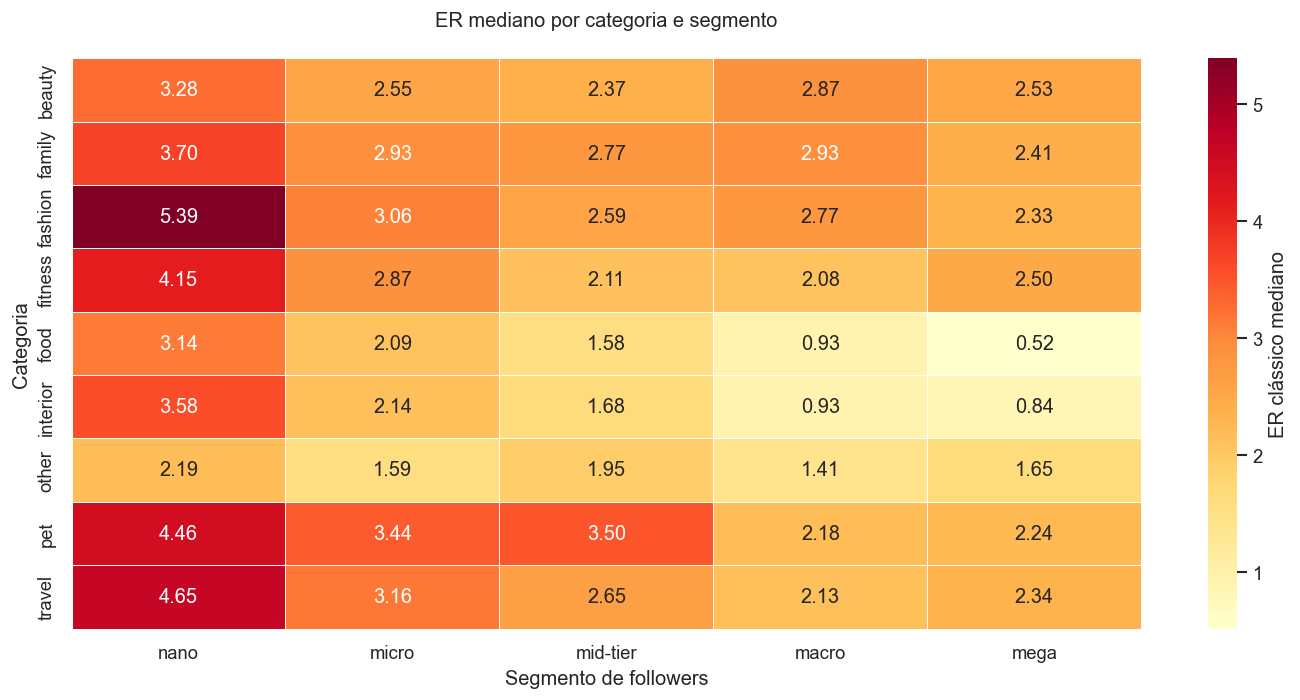

In [119]:
sweet_spot = (
    df.filter(pl.col("er_classico") > 0)
    .group_by(["inf_category", "bucket_followers"])
    .agg([
        pl.col("er_classico").median().round(4).alias("er_mediana"),
        pl.col("username").n_unique().alias("n_influenciadores"),
        pl.len().alias("n_posts"),
    ])
    .sort(["inf_category", "er_mediana"], descending=[False, True])
)

pivot_sweet = (
    sweet_spot.to_pandas()
    .pivot_table(index="inf_category", columns="bucket_followers", values="er_mediana")
    [ORDEM_BUCKET]
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    pivot_sweet, ax=ax,
    cmap="YlOrRd", annot=True, fmt=".2f",
    linewidths=0.3,
    cbar_kws={"label": "ER clássico mediano"},
)
ax.set_title(
    "ER mediano por categoria e segmento\n"
)
ax.set_xlabel("Segmento de followers")
ax.set_ylabel("Categoria")
plt.tight_layout()
plt.show()

- Volume de influenciadores por segmento e categoria

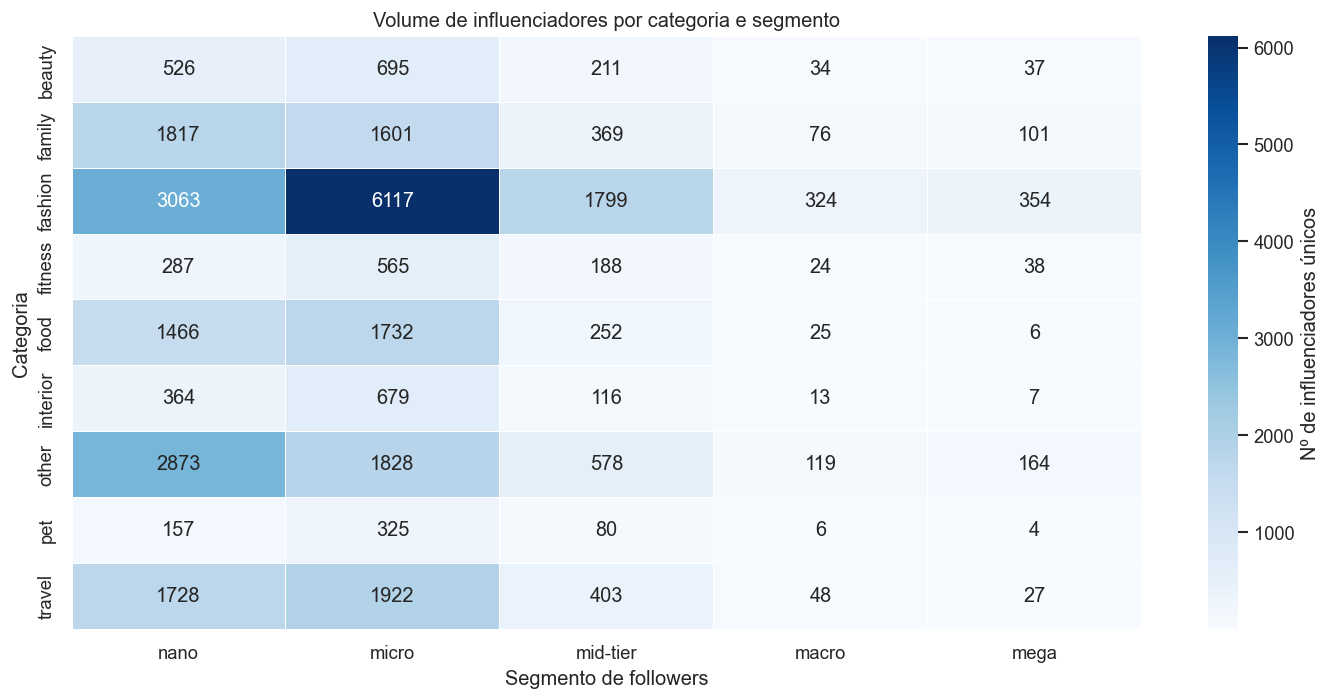

In [120]:
pivot_vol = (
    sweet_spot.to_pandas()
    .pivot_table(index="inf_category", columns="bucket_followers", values="n_influenciadores", fill_value=0)
    [ORDEM_BUCKET]
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    pivot_vol, ax=ax,
    cmap="Blues", annot=True, fmt=".0f",
    linewidths=0.3,
    cbar_kws={"label": "Nº de influenciadores únicos"},
)
ax.set_title("Volume de influenciadores por categoria e segmento")
ax.set_xlabel("Segmento de followers")
ax.set_ylabel("Categoria")
plt.tight_layout()
plt.show()

## 3.6 Correlações

- Correlações individuais com er_classico

In [121]:
variaveis = ["n_hashtags", "caption_len", "n_usertags", "aspect_ratio", "n_imagens"]

df_corr = (
    df.filter(pl.col("er_classico") > 0)
    .select(["er_classico"] + variaveis)
    .drop_nulls()
    .to_pandas()
)

resultados = []
for var in variaveis:
    corr, pval = spearmanr(df_corr["er_classico"], df_corr[var])
    resultados.append({"variavel": var, "spearman_r": round(corr, 4), "p_valor": round(pval, 6)})

df_res = pd.DataFrame(resultados).sort_values("spearman_r", key=abs, ascending=False)
print("Correlação de Spearman com er_classico:")
print(df_res.to_string(index=False))

Correlação de Spearman com er_classico:
    variavel  spearman_r  p_valor
  n_usertags      0.1674      0.0
aspect_ratio     -0.1286      0.0
  n_hashtags     -0.0324      0.0
   n_imagens      0.0235      0.0
 caption_len     -0.0048      0.0


Spearman em vez de pearson pois é mais robusto a outliers.

- Matriz de correlação das variaveis relevantes

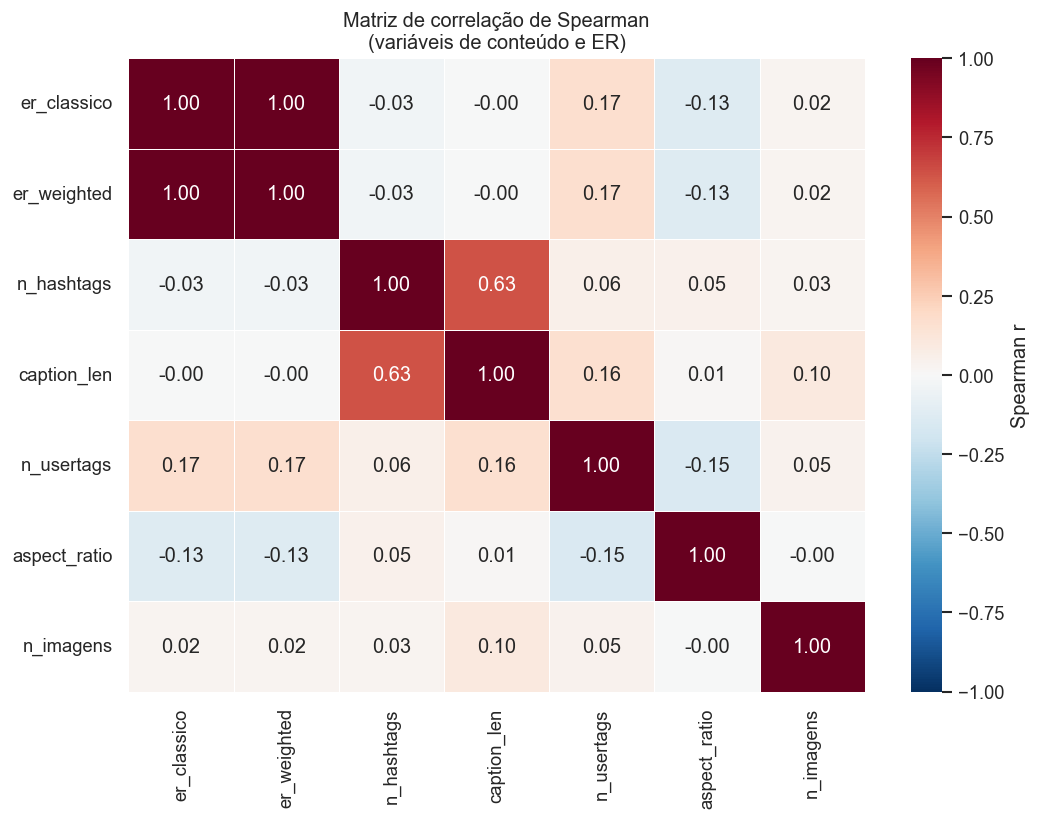

In [122]:
cols_matrix = ["er_classico", "er_weighted"] + variaveis

df_matrix = (
    df.filter(pl.col("er_classico") > 0)
    .select(cols_matrix)
    .drop_nulls()
    .to_pandas()
)

corr_matrix = df_matrix.corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix, ax=ax,
    cmap="RdBu_r", center=0,
    vmin=-1, vmax=1,
    annot=True, fmt=".2f",
    linewidths=0.3,
    cbar_kws={"label": "Spearman r"},
)
ax.set_title("Matriz de correlação de Spearman\n(variáveis de conteúdo e ER)")
plt.tight_layout()
plt.show()

## 3.7 Padrões temporais

- ER medio por ano

In [123]:
er_ano = (
    df.filter(
        pl.col("er_classico") > 0,
        pl.col("data_dt").is_not_null(),
    )
    .with_columns(pl.col("data_dt").dt.year().alias("ano"))
    .group_by("ano")
    .agg([
        pl.col("er_classico").median().round(4).alias("er_mediana"),
        pl.col("er_classico").mean().round(4).alias("er_media"),
        pl.len().alias("n_posts"),
    ])
    .sort("ano")
)
er_ano

ano,er_mediana,er_media,n_posts
i32,f64,f64,u32
2012,0.3398,0.7904,1511
2013,0.8666,1.6782,10341
2014,1.5765,2.6721,34828
2015,1.8043,2.9304,115222
2016,2.2448,3.2736,506945
2017,2.9415,4.0222,1776191
2018,3.1353,4.3566,5159751
2019,2.7778,4.535,1958854


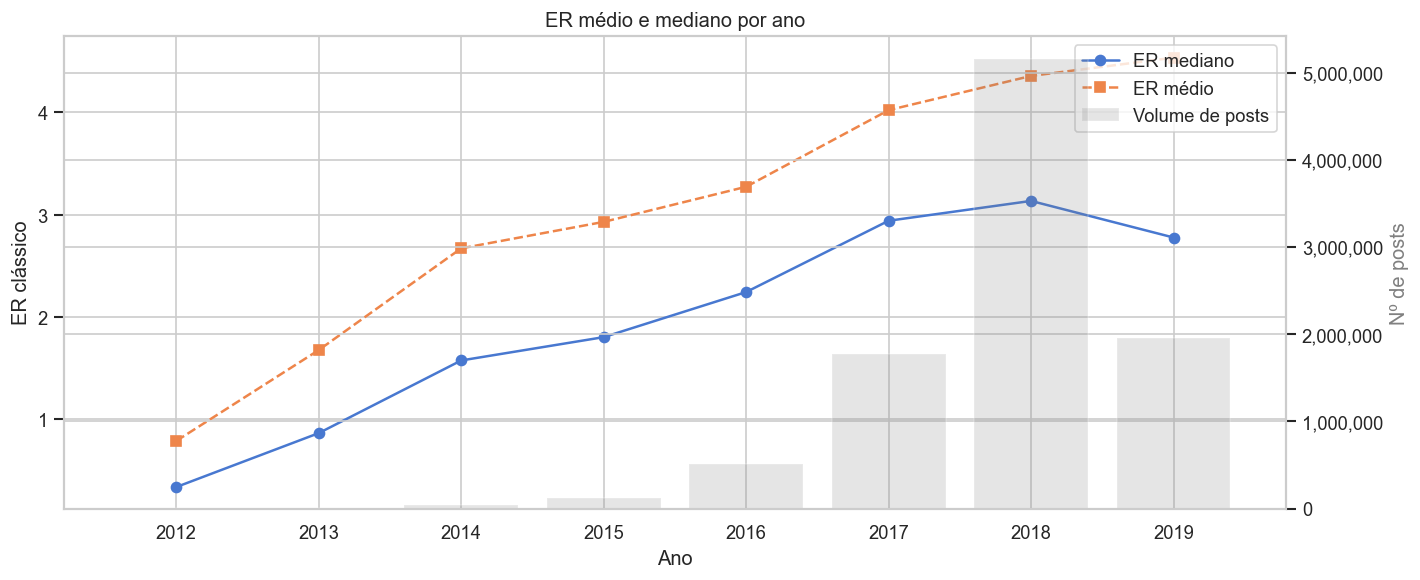

In [124]:

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()   # eixo secundário para volume de posts

anos = er_ano["ano"].to_list()
ax1.plot(anos, er_ano["er_mediana"].to_list(), marker="o", color=sns.color_palette("muted")[0], label="ER mediano")
ax1.plot(anos, er_ano["er_media"].to_list(),   marker="s", color=sns.color_palette("muted")[1], label="ER médio", linestyle="--")
ax2.bar(anos, er_ano["n_posts"].to_list(), alpha=0.2, color="gray", label="Volume de posts")

ax1.set_xlabel("Ano")
ax1.set_ylabel("ER clássico")
ax2.set_ylabel("Nº de posts", color="gray")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax1.set_title("ER médio e mediano por ano")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.tight_layout()
plt.show()

- Distribuição mensal de ER classico

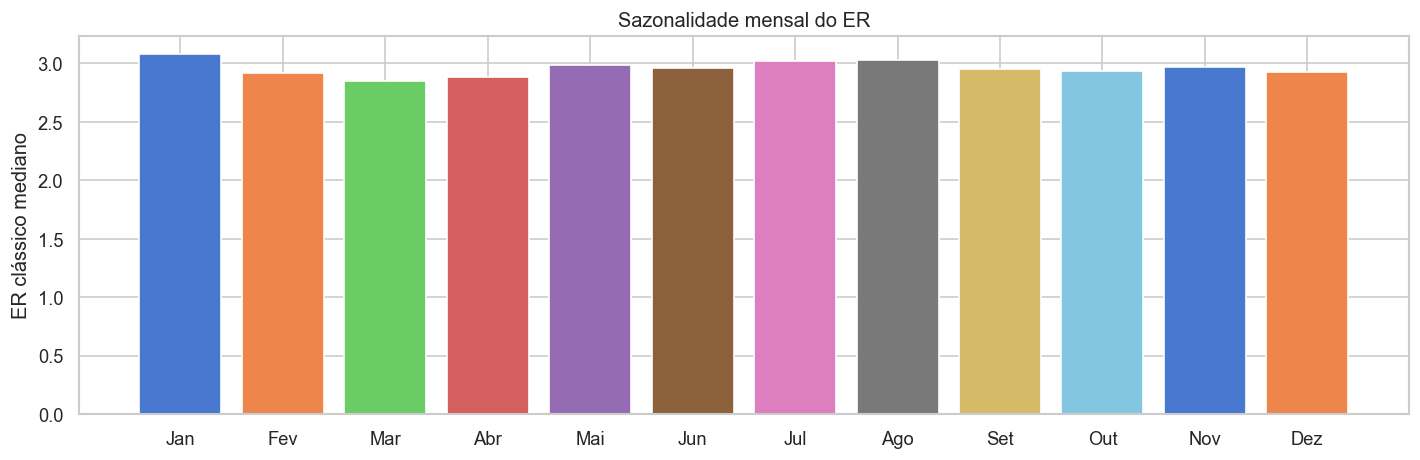

In [125]:
MESES = ["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"]

er_mes = (
    df.filter(
        pl.col("er_classico") > 0,
        pl.col("data_dt").is_not_null(),
    )
    .with_columns(pl.col("data_dt").dt.month().alias("mes"))
    .group_by("mes")
    .agg([
        pl.col("er_classico").median().round(4).alias("er_mediana"),
        pl.len().alias("n_posts"),
    ])
    .sort("mes")
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(
    er_mes["mes"].to_list(),
    er_mes["er_mediana"].to_list(),
    color=sns.color_palette("muted", 12),
)
ax.set_xticks(er_mes["mes"].to_list())
ax.set_xticklabels(MESES)
ax.set_ylabel("ER clássico mediano")
ax.set_title("Sazonalidade mensal do ER")
plt.tight_layout()
plt.show()

# Conclusões

#### A mediana dos comentarios é 0 em todas as categorias (3.2) 
Se a maioria absoluta dos posts tem 0 comentários, o pexo x2 no er_weighted so se aplica a uma minoria de posts. O que significa que para a maioria do dataset er_classico = er_weighted. Precisamos explorar outros sinais além de likes e comments

#### A relação inversa entre ER e tamanho da conta (3.5)
Não basta ter muitos seguidores, contas menores têm audiências proporcionalmente mais engajadas. Isso suporta que métricas brutas de alcance são insuficientes.

#### Buckets da indústria (2.3.1)

21.27% VIRAL e 14.76% LOW, é contra-intuitivo. Pode ser que os labels da industria foram calibrados para contas maiores.

Considerar aplicar o Engagement Rate Value Range de arman

#### Em 100% do dataset, posts patrocinados tem ER menor que organicos (3.3)
Talvez a audiencia responde menos a conteudo pago, e posts patrocinados contaminam o ER médio do influenciador.

Pode ser que aplicar uma penalidade para posts patrocinados pode ser importante para qualificar a audiência

#### Carrossel supera Imagem em todas as categorias (3.4)

A diferença nas medianas de ER é pequena, mas pode ser por conta da quantidade de posts em cada tipo. Vale analisar.

Uma limitação percebida no dataset é que não há dados de posts do tipo video.

# Perguntas que ficam

- er_weighted diferencia de forma significativa os influencers em comparação com er_classico?
- Nano influenciadores têm er maior porque a audiência é mais engajada ou porque o algoritmo favorece?
- Posts organicos são um representante melhor de qualidade de audiência do que os patrocinados?
- Os labels da industria são adequados para todos os segmentos de tamanho, ou precisam de calibração por segmento?(os dados ja sugerem que precisam de calibração)
- Faz sentido comparar influenciadores de categorias e segmentos(de tamanho da audiencia) diferentes?

# 4.0 Pós Conclusões
Aqui implemento alguns pontos que ficaram em destaque na analise até agora, e para não interromper o fluxo de pensamento, vou implementar a seguir.

In [126]:
df = pl.read_parquet("posts_processado.parquet")

## 4.1 Coeficiente de Variação do er por influenciador
- cv = std/mean x 100

Se o coeficiente de variação (cv) de um influenciador é baixo, então seu engajamento é consistente, logo, audiência mais confiável.

In [127]:
df_cv_influenciador = (
    df.filter(
        (pl.col("er_classico") > 0) &
        (pl.col("er_classico") < 100)   # remove outliers impossíveis
    )
    .group_by("username")
    .agg([
        pl.col("er_classico").mean().alias("er_media"),
        pl.col("er_classico").std().alias("er_std"),
        pl.col("er_classico").median().alias("er_mediana"),
        pl.col("er_classico").quantile(0.25).alias("er_p25"),
        pl.col("er_classico").quantile(0.75).alias("er_p75"),
        pl.col("er_classico").count().alias("n_posts_validos"),
        pl.col("inf_category").first().alias("categoria"),
        pl.col("followers").first().alias("followers"),
        pl.col("bucket_followers").first().alias("bucket_followers"),
    ])
    .with_columns([
        (pl.col("er_std") / pl.col("er_media") * 100).alias("cv_er")
    ])
    .filter(pl.col("n_posts_validos") >= 10)  # mínimo para CV ser significativo
    .sort("cv_er")
)

In [128]:
len(df_cv_influenciador)

33113

In [129]:
df_cv_influenciador

username,er_media,er_std,er_mediana,er_p25,er_p75,n_posts_validos,categoria,followers,bucket_followers,cv_er
str,f64,f64,f64,f64,f64,u32,str,i64,str,f64
"""marta__lu""",1.225535,0.053759,1.218085,1.201211,1.238122,232,"""fashion""",94821,"""micro""",4.386611
"""mr_youngblood_fitness""",4.651766,0.277315,4.622572,4.529137,4.720925,300,"""other""",20335,"""micro""",5.961506
"""leah_stauffer""",3.744877,0.237283,3.725429,3.641632,3.820589,280,"""family""",35204,"""micro""",6.336191
"""chocobi8011""",3.122739,0.201389,3.135649,3.014417,3.227392,300,"""food""",91560,"""micro""",6.449124
"""kathryneisman""",1.692156,0.114225,1.680569,1.631213,1.742263,299,"""family""",40522,"""micro""",6.750267
…,…,…,…,…,…,…,…,…,…,…
"""iluvsylvia""",0.782978,3.61883,0.252451,0.102345,0.957171,184,"""other""",102594,"""mid-tier""",462.188179
"""chefmitchiesmunchies""",1.066686,4.959459,0.582242,0.357285,0.886595,297,"""other""",7557,"""nano""",464.941041
"""thismamas""",1.164602,5.477462,0.291511,0.198228,1.201026,299,"""family""",8576,"""nano""",470.32919


In [130]:
df_cv_influenciador.group_by("bucket_followers").agg([
        pl.col("cv_er").mean().alias("cv_medio"),
        pl.col("cv_er").median().alias("cv_mediano"),
        pl.col("cv_er").std().alias("cv_std"),
        pl.len().alias("n_influenciadores"),
    ]).sort("cv_medio")

bucket_followers,cv_medio,cv_mediano,cv_std,n_influenciadores
str,f64,f64,f64,u32
"""mid-tier""",56.614244,50.049279,29.164058,3992
"""micro""",57.029504,50.174352,30.575168,15454
"""nano""",57.52479,49.192089,33.385676,12261
"""macro""",62.193462,54.996178,32.907652,668
"""mega""",64.790496,59.916777,26.086319,738


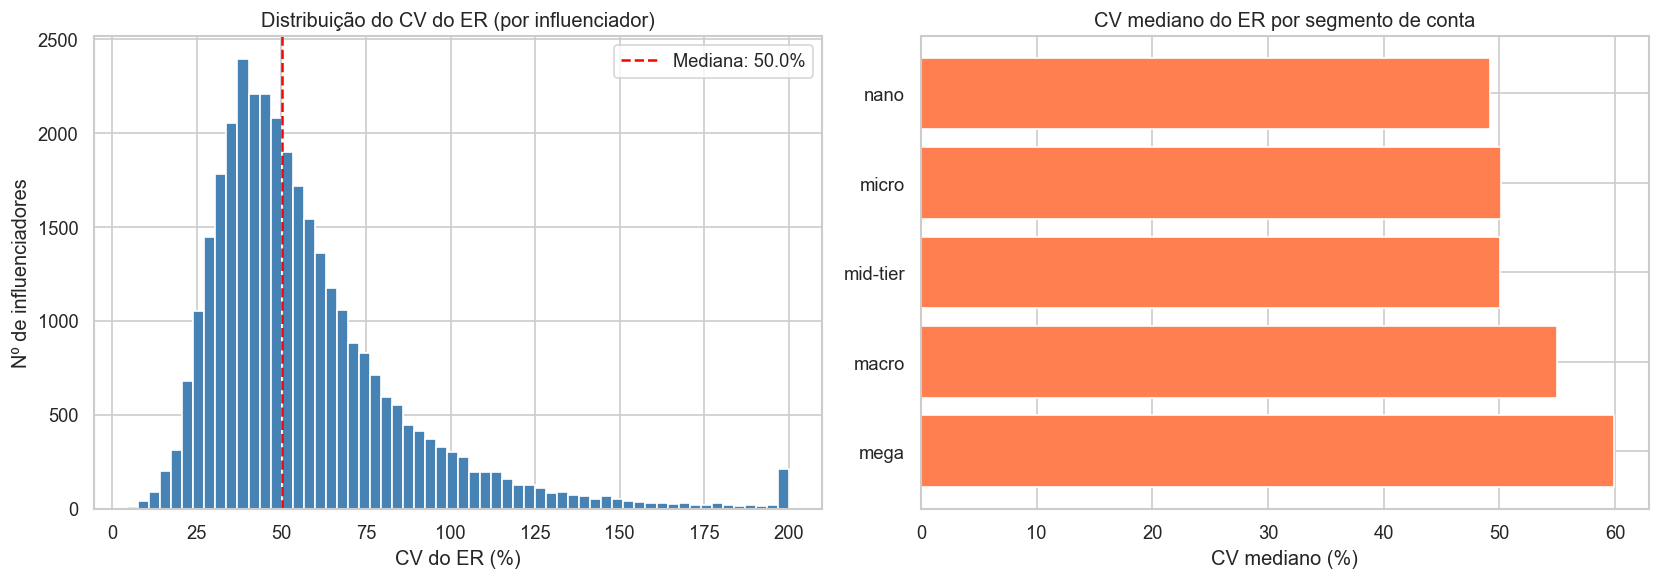

In [131]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição do CV geral
cv_pd = df_cv_influenciador.to_pandas()
axes[0].hist(cv_pd["cv_er"].clip(upper=200), bins=60, color="steelblue", edgecolor="white")
axes[0].axvline(cv_pd["cv_er"].median(), color="red", linestyle="--",
                label=f"Mediana: {cv_pd['cv_er'].median():.1f}%")
axes[0].set_title("Distribuição do CV do ER (por influenciador)")
axes[0].set_xlabel("CV do ER (%)")
axes[0].set_ylabel("Nº de influenciadores")
axes[0].legend()

# CV por bucket de followers
ordem = ["nano","micro","mid-tier","macro","mega"]
cv_bucket = (
    df_cv_influenciador.group_by("bucket_followers")
    .agg(pl.col("cv_er").median().alias("cv_mediano"))
    .to_pandas()
    .set_index("bucket_followers")
    .reindex(ordem)
    .reset_index()
)
axes[1].barh(cv_bucket["bucket_followers"], cv_bucket["cv_mediano"], color="coral")
axes[1].set_title("CV mediano do ER por segmento de conta")
axes[1].set_xlabel("CV mediano (%)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("cv_er_influenciador.png", dpi=150)
plt.show()

## 4.2 Adapted Bucket - Inspirado em Arman(2019)

O er deve ser avaliado com relação ao tamanho da conta. Um ER de 3% é excelente para uma conta Mega, mas abaixo da media para uma conta Nano

1. Calular media e std do er_classico por bucket_followers

In [132]:
thresholds = (
    df.filter(
        (pl.col("er_classico") > 0) &
        (pl.col("er_classico") < 100)
    )
    .group_by("bucket_followers")
    .agg([
        pl.col("er_classico").mean().alias("er_media_bucket"),
        pl.col("er_classico").std().alias("er_std_bucket"),
    ])
    .with_columns([
        (pl.col("er_media_bucket") - 0.5 * pl.col("er_std_bucket")).alias("thresh_low"),
        (pl.col("er_media_bucket") + 0.5 * pl.col("er_std_bucket")).alias("thresh_high"),
    ])
)

thresholds.sort("er_media_bucket", descending=True)

bucket_followers,er_media_bucket,er_std_bucket,thresh_low,thresh_high
str,f64,f64,f64,f64
"""nano""",5.205158,5.33757,2.536373,7.873943
"""micro""",3.750341,3.911369,1.794656,5.706025
"""mid-tier""",3.394217,3.508127,1.640154,5.148281
"""macro""",3.332506,3.60182,1.531596,5.133416
"""mega""",3.052291,3.196101,1.45424,4.650341


2. Aplicar os thresholds a cada post via join

In [133]:
df = df.join(thresholds, on="bucket_followers",how="left")

df = df.with_columns([
    pl.when(pl.col("er_classico") < pl.col("thresh_low"))
        .then(pl.lit("LOW"))
    .when(pl.col("er_classico") <= pl.col("thresh_high"))
        .then(pl.lit("MEDIUM"))
    .otherwise(pl.lit("HIGH"))
    .alias("adapted_bucket")
])

In [134]:
df.head()

post_id,username,inf_category,followers,followees,posts_total,is_verified,data,timestamp_unix,likes,comments_count,post_type,n_imagens,aspect_ratio,is_sponsored,n_hashtags,n_usertags,caption_len,has_location,accessibility,data_dt,engajamento_zero,er_classico,er_weighted,bucket_followers,er_bucket_industria,er_bucket_percentil,er_media_bucket,er_std_bucket,thresh_low,thresh_high,adapted_bucket
str,str,str,i64,i64,i64,bool,str,i64,i64,i64,str,i64,f64,bool,i64,i64,i64,bool,str,date,bool,f64,f64,str,str,str,f64,f64,f64,f64,str
"""BmlIb5Xld5f""","""00s_supermodels""","""fashion""",2031,53,2520,false,"""2018-08-17""",1534509290,51,2,"""image""",1,0.8,false,18,1,257,false,"""""",2018-08-17,false,2.609552,2.708026,"""nano""","""MEDIUM""","""Q2""",5.205158,5.33757,2.536373,7.873943,"""MEDIUM"""
"""BmlI2LPlblP""","""00s_supermodels""","""fashion""",2031,53,2520,false,"""2018-08-17""",1534509505,89,0,"""image""",1,0.8,false,17,1,279,false,"""""",2018-08-17,false,4.382078,4.382078,"""nano""","""HIGH""","""Q3""",5.205158,5.33757,2.536373,7.873943,"""MEDIUM"""
"""BmoH1VclTxO""","""00s_supermodels""","""fashion""",2031,53,2520,false,"""2018-08-18""",1534609638,94,0,"""image""",1,0.8,false,16,1,228,false,"""""",2018-08-18,false,4.628262,4.628262,"""nano""","""HIGH""","""Q3""",5.205158,5.33757,2.536373,7.873943,"""MEDIUM"""
"""Bmd0fuolkUZ""","""00s_supermodels""","""fashion""",2031,53,2520,false,"""2018-08-14""",1534263955,66,4,"""carousel""",2,0.8,true,17,1,282,false,"""Image may contain: 2 people, i…",2018-08-14,false,3.446578,3.643525,"""nano""","""MEDIUM""","""Q3""",5.205158,5.33757,2.536373,7.873943,"""MEDIUM"""
"""Bmd445DFh7t""","""00s_supermodels""","""fashion""",2031,53,2520,false,"""2018-08-14""",1534266258,64,0,"""carousel""",4,0.8,false,18,1,255,false,"""Image may contain: 1 person, c…",2018-08-14,false,3.151157,3.151157,"""nano""","""MEDIUM""","""Q3""",5.205158,5.33757,2.536373,7.873943,"""MEDIUM"""


3. Distribuição do adapted_bucket

In [135]:
dist_adapted = df.group_by("adapted_bucket").agg(pl.len().alias("n_posts")).with_columns(
        (pl.col("n_posts") / pl.col("n_posts").sum() * 100).round(2).alias("pct")
    ).sort("n_posts", descending=True)
dist_adapted

adapted_bucket,n_posts,pct
str,u32,f64
"""MEDIUM""",4509038,47.13
"""LOW""",3229252,33.76
"""HIGH""",1828361,19.11


- Aqui podemos identificar um problema, a estratégia de utilizar Mean +- 0.5std não foi uma boa ideia para os dados atuais, pois, como er_media ~ er_std percebemos que à uma cauda a direita(posts virais com er muito alto) que distorce os parametros, vamos testar outras opções a seguir

### Mediana + MAD(Median Absolute Deviation)
MAD = mediana(|ER_i - mediana(ER)|)\
Thresholds: LOW < mediana - k*MAD | MÉDIO: mediana ± k*MAD | ALTO > mediana + k*MAD\
k = 1.0 (equivalente robusto de ±1σ) — ajustável

In [136]:
K_MAD = 1.0

In [137]:
thresholds_mad = (
    df.filter(
        (pl.col("er_classico") > 0) &
        (pl.col("er_classico") < 100)
    )
    .group_by("bucket_followers")
    .agg([
        pl.col("er_classico").median().alias("er_mediana_bucket"),
        # MAD: mediana dos desvios absolutos em relação à mediana
        (pl.col("er_classico") - pl.col("er_classico").median())
            .abs()
            .median()
            .alias("mad_bucket"),
    ])
    .with_columns([
        (pl.col("er_mediana_bucket") - K_MAD * pl.col("mad_bucket")).alias("thresh_low_mad"),
        (pl.col("er_mediana_bucket") + K_MAD * pl.col("mad_bucket")).alias("thresh_high_mad"),
    ])
)

print("Thresholds : Mediana + MAD (k=1.0)")
thresholds_mad.sort("er_mediana_bucket", descending=True)

Thresholds : Mediana + MAD (k=1.0)


bucket_followers,er_mediana_bucket,mad_bucket,thresh_low_mad,thresh_high_mad
str,f64,f64,f64,f64
"""nano""",3.717827,2.1784,1.539427,5.896226
"""micro""",2.710101,1.520933,1.189169,4.231034
"""mid-tier""",2.404068,1.336262,1.067806,3.740329
"""macro""",2.288757,1.449677,0.839081,3.738434
"""mega""",2.147214,1.359406,0.787809,3.50662


In [138]:
df = df.join(thresholds_mad, on="bucket_followers", how="left")

df = df.with_columns([
    pl.when(pl.col("er_classico") <= 0)
        .then(pl.lit(None))
    .when(pl.col("er_classico") < pl.col("thresh_low_mad"))
        .then(pl.lit("LOW"))
    .when(pl.col("er_classico") <= pl.col("thresh_high_mad"))
        .then(pl.lit("MÉDIO"))
    .otherwise(pl.lit("ALTO"))
    .alias("adapted_bucket_mad")
])

In [139]:
dist_mad = (
    df.filter(pl.col("adapted_bucket_mad").is_not_null())
    .group_by("adapted_bucket_mad")
    .agg(pl.len().alias("n"))
    .with_columns(
        (pl.col("n") / pl.col("n").sum() * 100).round(2).alias("pct")
    )
    .sort("n", descending=True)
)
print("\nDistribuição geral (MAD):")
dist_mad


Distribuição geral (MAD):


adapted_bucket_mad,n,pct
str,u32,f64
"""MÉDIO""",4781057,49.99
"""ALTO""",2897318,30.3
"""LOW""",1885268,19.71


In [140]:
dist_mad_seg = (
    df.filter(pl.col("adapted_bucket_mad").is_not_null())
    .group_by(["bucket_followers", "adapted_bucket_mad"])
    .agg(pl.len().alias("n"))
    .with_columns(
        (pl.col("n") / pl.col("n").sum().over("bucket_followers") * 100)
        .round(1).alias("pct_no_segmento")
    )
    .sort(["bucket_followers", "adapted_bucket_mad"])
)
print("\nDistribuição por segmento (MAD):")
dist_mad_seg


Distribuição por segmento (MAD):


bucket_followers,adapted_bucket_mad,n,pct_no_segmento
str,str,u32,f64
"""macro""","""ALTO""",59145,30.6
"""macro""","""LOW""",37602,19.4
"""macro""","""MÉDIO""",96748,50.0
"""mega""","""ALTO""",65244,30.6
"""mega""","""LOW""",41437,19.4
…,…,…,…
"""mid-tier""","""LOW""",228472,19.8
"""mid-tier""","""MÉDIO""",578340,50.0
"""nano""","""ALTO""",1073013,30.5


### Percentis P25/P75/P90
\< P25 -> LOW    (abaixo do quartil inferior)\
P25 a P75 -> MEDIUM (intervalo interquartílico, comportamento típico)\
P75 a P90 -> HIGH   (acima da mediana superior, abaixo do top 10%)\
\> P90 -> VIRAL  (top 10% do segmento)

In [141]:
thresholds_pct = (
    df.filter(
        (pl.col("er_classico") > 0) &
        (pl.col("er_classico") < 100)
    )
    .group_by("bucket_followers")
    .agg([
        pl.col("er_classico").quantile(0.25).alias("p25"),
        pl.col("er_classico").quantile(0.75).alias("p75"),
        pl.col("er_classico").quantile(0.90).alias("p90"),
        pl.col("er_classico").median().alias("mediana"),
        pl.len().alias("n_posts"),
    ])
)

print("Thresholds - Percentis por segmento")
thresholds_pct.sort("mediana", descending=True)

Thresholds - Percentis por segmento


bucket_followers,p25,p75,p90,mediana,n_posts
str,f64,f64,f64,f64,u32
"""nano""",1.886792,6.772811,11.025145,3.717827,3521107
"""micro""",1.426703,4.80336,7.772482,2.710101,4477429
"""mid-tier""",1.280946,4.292392,7.20556,2.404068,1156679
"""macro""",1.060649,4.346021,7.359569,2.288757,193495
"""mega""",0.998368,4.044924,6.593368,2.147214,213358


In [142]:
df = df.join(thresholds_pct, on="bucket_followers", how="left")

df = df.with_columns([
    pl.when(pl.col("er_classico") <= 0)
        .then(pl.lit(None))
    .when(pl.col("er_classico") < pl.col("p25"))
        .then(pl.lit("LOW"))
    .when(pl.col("er_classico") < pl.col("p75"))
        .then(pl.lit("MEDIUM"))
    .when(pl.col("er_classico") < pl.col("p90"))
        .then(pl.lit("HIGH"))
    .otherwise(pl.lit("VIRAL"))
    .alias("adapted_bucket_pct")
])

In [143]:
dist_pct = (
    df.filter(pl.col("adapted_bucket_pct").is_not_null())
    .group_by("adapted_bucket_pct")
    .agg(pl.len().alias("n"))
    .with_columns(
        (pl.col("n") / pl.col("n").sum() * 100).round(2).alias("pct")
    )
    .sort("n", descending=True)
)
print("\nDistribuição geral (Percentis):")
dist_pct


Distribuição geral (Percentis):


adapted_bucket_pct,n,pct
str,u32,f64
"""MEDIUM""",4781252,49.99
"""LOW""",2390296,24.99
"""HIGH""",1434304,15.0
"""VIRAL""",957791,10.01


In [144]:
dist_pct_seg = (
    df.filter(pl.col("adapted_bucket_pct").is_not_null())
    .group_by(["bucket_followers", "adapted_bucket_pct"])
    .agg(pl.len().alias("n"))
    .with_columns(
        (pl.col("n") / pl.col("n").sum().over("bucket_followers") * 100)
        .round(1).alias("pct_no_segmento")
    )
    .sort(["bucket_followers", "adapted_bucket_pct"])
)
print("\nDistribuição por segmento (Percentis):")
dist_pct_seg


Distribuição por segmento (Percentis):


bucket_followers,adapted_bucket_pct,n,pct_no_segmento
str,str,u32,f64
"""macro""","""HIGH""",29024,15.0
"""macro""","""LOW""",48374,25.0
"""macro""","""MEDIUM""",96747,50.0
"""macro""","""VIRAL""",19350,10.0
"""mega""","""HIGH""",32003,15.0
…,…,…,…
"""mid-tier""","""VIRAL""",115691,10.0
"""nano""","""HIGH""",528163,15.0
"""nano""","""LOW""",880056,25.0


### Comparação das três estratégias

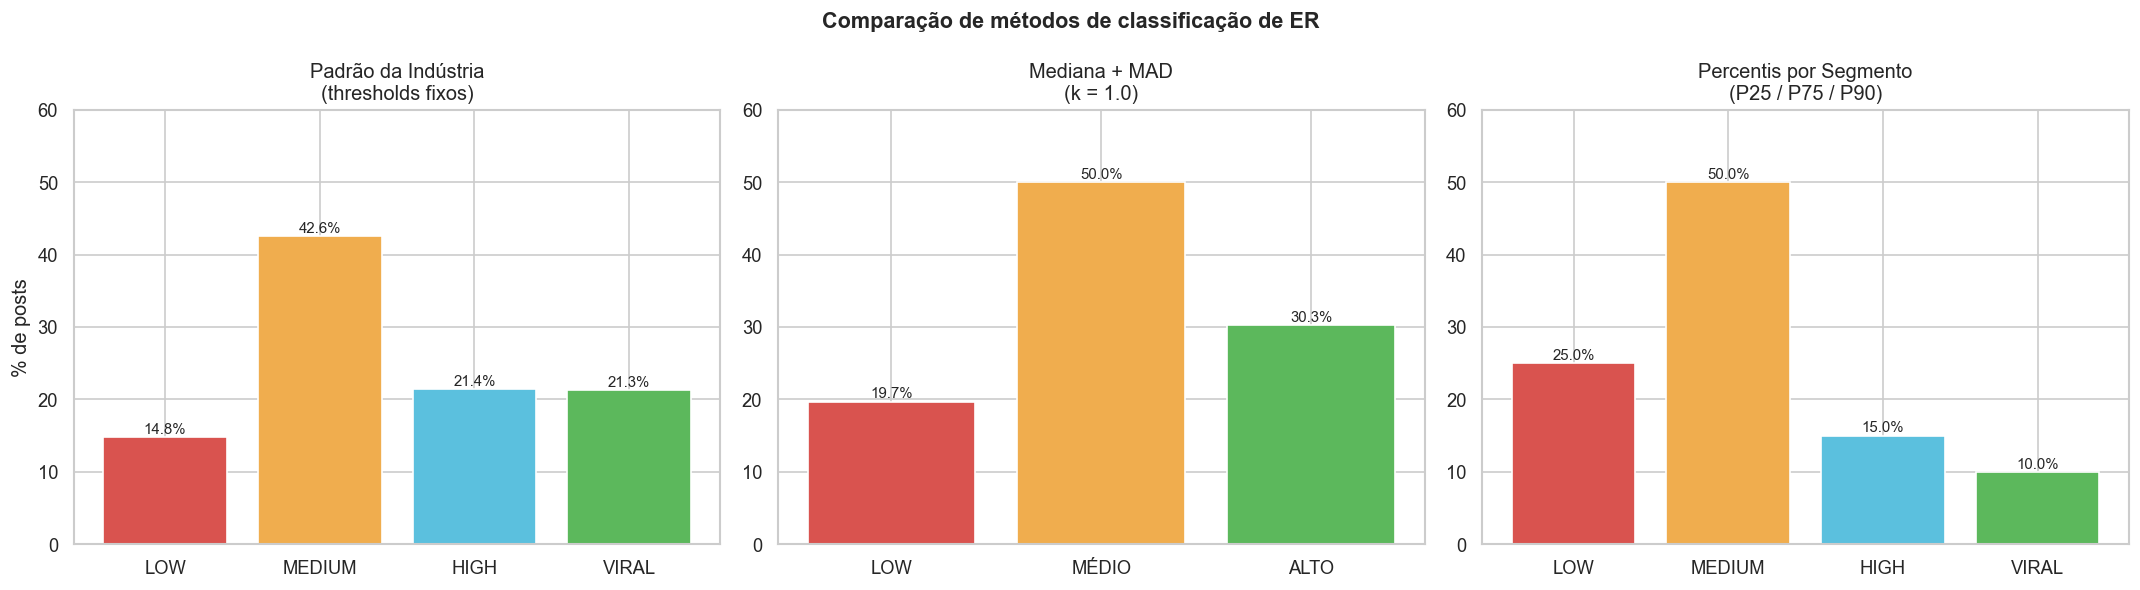

In [145]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Comparação de métodos de classificação de ER", fontsize=13, fontweight="bold")

CORES_3 = {"LOW": "#d9534f", "MÉDIO": "#f0ad4e", "ALTO": "#5cb85c"}
CORES_4 = {"LOW": "#d9534f", "MEDIUM": "#f0ad4e", "HIGH": "#5bc0de", "VIRAL": "#5cb85c"}

# ── Painel 1: Indústria (já calculado) ───────────────────────────────────────
ind = (
    df.group_by("er_bucket_industria")
    .agg(pl.len().alias("n"))
    .with_columns((pl.col("n") / pl.col("n").sum() * 100).round(2).alias("pct"))
    .to_pandas().set_index("er_bucket_industria")
    .reindex(["LOW","MEDIUM","HIGH","VIRAL"]).reset_index()
)
bars = axes[0].bar(ind["er_bucket_industria"], ind["pct"],
                   color=[CORES_4[l] for l in ind["er_bucket_industria"]])
axes[0].set_title("Padrão da Indústria\n(thresholds fixos)")
axes[0].set_ylabel("% de posts")
axes[0].set_ylim(0, 60)
for bar, v in zip(bars, ind["pct"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)

# ── Painel 2: MAD ─────────────────────────────────────────────────────────────
mad_pd = dist_mad.to_pandas().set_index("adapted_bucket_mad")
ordem_mad = ["LOW","MÉDIO","ALTO"]
mad_pd = mad_pd.reindex(ordem_mad).reset_index()
bars = axes[1].bar(mad_pd["adapted_bucket_mad"], mad_pd["pct"],
                   color=[CORES_3[l] for l in mad_pd["adapted_bucket_mad"]])
axes[1].set_title("Mediana + MAD\n(k = 1.0)")
axes[1].set_ylim(0, 60)
for bar, v in zip(bars, mad_pd["pct"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)

# ── Painel 3: Percentis ───────────────────────────────────────────────────────
pct_pd = dist_pct.to_pandas().set_index("adapted_bucket_pct")
ordem_pct = ["LOW","MEDIUM","HIGH","VIRAL"]
pct_pd = pct_pd.reindex(ordem_pct).reset_index()
bars = axes[2].bar(pct_pd["adapted_bucket_pct"], pct_pd["pct"],
                   color=[CORES_4[l] for l in pct_pd["adapted_bucket_pct"]])
axes[2].set_title("Percentis por Segmento\n(P25 / P75 / P90)")
axes[2].set_ylim(0, 60)
for bar, v in zip(bars, pct_pd["pct"]):
    axes[2].text(bar.get_x() + bar.get_width()/2, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("comparacao_tres_metodos.png", dpi=150)
plt.show()

In [146]:
resumo = (
    thresholds_mad
    .join(thresholds_pct, on="bucket_followers")
    .select([
        "bucket_followers",
        pl.col("er_mediana_bucket").round(3).alias("mediana"),
        pl.col("thresh_low_mad").round(3).alias("MAD_low_thresh"),
        pl.col("thresh_high_mad").round(3).alias("MAD_high_thresh"),
        pl.col("p25").round(3).alias("PCT_p25"),
        pl.col("p75").round(3).alias("PCT_p75"),
        pl.col("p90").round(3).alias("PCT_p90"),
    ])
    .sort("mediana", descending=True)
)
resumo

bucket_followers,mediana,MAD_low_thresh,MAD_high_thresh,PCT_p25,PCT_p75,PCT_p90
str,f64,f64,f64,f64,f64,f64
"""nano""",3.718,1.539,5.896,1.887,6.773,11.025
"""micro""",2.71,1.189,4.231,1.427,4.803,7.772
"""mid-tier""",2.404,1.068,3.74,1.281,4.292,7.206
"""macro""",2.289,0.839,3.738,1.061,4.346,7.36
"""mega""",2.147,0.788,3.507,0.998,4.045,6.593


# Conclusões pt2

#### Contas Maiores tem coeficiente de variação maiores que contas menores 


#### O CV pode servir como penalizador
Um influenciador com er médio alto mas cv grande é menos confiavel do que um com er medio baixo mas com cv menor

#### A comparação dos métodos de segmentação mostrou que os buckets adaptados com os percentis(adapted_buckets_pct) se sairam melhor

A distribuição final forma uma pirâmide coerente onde as categorias superiores são mais raras.

O método de percentis por segmento é o adotado daqui pra frente, por produzir uma piramide interpretável e permitir comparação relativa consistente entre segmentos de diferentes tamanhos.

# Salvando posts_processado.parquet


In [147]:
# Remove colunas intermediárias dos métodos não adotados antes de salvar
df_final = df.drop([
    # Colunas auxiliares do mean+std (método original descartado)
    "er_media_bucket",
    "er_std_bucket", 
    "thresh_low",
    "thresh_high",
    "adapted_bucket",        # era o mean+std, substituído

    # Colunas auxiliares do MAD (mantido só como análise, não como coluna final)
    "er_mediana_bucket",
    "mad_bucket",
    "thresh_low_mad",
    "thresh_high_mad",
    "adapted_bucket_mad",    # descartado em favor do percentil

    # Colunas auxiliares do percentil (thresholds numéricos, não precisam ficar no parquet)
    "p25",
    "p75",
    "p90",
    "mediana",               # coluna gerada pelo join dos thresholds
    "n_posts",               # coluna gerada pelo join dos thresholds
])

In [148]:
df_final.write_parquet("posts_processado.parquet", compression="zstd")

print(f"Salvo: posts_processado.parquet")
print(f"Shape: {df_final.shape[0]:,} linhas × {df_final.shape[1]} colunas")
print(f"\nColunas finais:")
print(df_final.schema)

Salvo: posts_processado.parquet
Shape: 9,566,651 linhas × 28 colunas

Colunas finais:
Schema({'post_id': String, 'username': String, 'inf_category': String, 'followers': Int64, 'followees': Int64, 'posts_total': Int64, 'is_verified': Boolean, 'data': String, 'timestamp_unix': Int64, 'likes': Int64, 'comments_count': Int64, 'post_type': String, 'n_imagens': Int64, 'aspect_ratio': Float64, 'is_sponsored': Boolean, 'n_hashtags': Int64, 'n_usertags': Int64, 'caption_len': Int64, 'has_location': Boolean, 'accessibility': String, 'data_dt': Date, 'engajamento_zero': Boolean, 'er_classico': Float64, 'er_weighted': Float64, 'bucket_followers': String, 'er_bucket_industria': String, 'er_bucket_percentil': String, 'adapted_bucket_pct': String})


In [149]:
# Salvar tabela de CV por influenciador
df_cv_influenciador.write_parquet("influenciadores_cv.parquet", compression="zstd")
print(f"Salvo: influenciadores_cv.parquet — {len(df_cv_influenciador):,} influenciadores")

Salvo: influenciadores_cv.parquet — 33,113 influenciadores
